# 27.2 · NMS and duplicate predictions

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain nms and duplicate predictions using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[12 · Contours and Shapes](../../12-contours-and-shapes/README.md), [22 · Machine Learning for Vision](../../22-machine-learning-for-vision/README.md), [24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [26 · Transfer Learning](../../26-transfer-learning/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Object detection predicts both location and class. A detector can produce several overlapping proposals, so evaluation must match predictions to ground-truth objects and count duplicates correctly. Localization and classification errors are different failure modes.

## 2. Intuition

Greedy NMS keeps the highest-scoring box and removes lower-scoring boxes with excessive overlap, then repeats. Apply class-aware suppression when overlapping objects of different classes can coexist. NMS can remove a real nearby object; modern set-prediction methods may use different duplicate-control mechanisms.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 27
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
IoU(A,B)=|A\cap B|/(|A|+|B|-|A\cap B|)
$$

A and B are regions and vertical bars denote area. Two 2×2 boxes overlapping in a 1×1 region have intersection 1, union 7 and IoU=1/7.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
area_a, area_b, intersection = 4.0, 4.0, 1.0
iou = intersection / (area_a + area_b - intersection)
assert np.isclose(iou, 1 / 7)
print(iou)

0.14285714285714285


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The NumPy implementation computes vectorized intersection/union and greedy suppression. Precision/recall are calculated from sorted scores and explicit true/false match flags.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def detection(lesson, seed, amount):
    boxes = np.array([[10, 10, 50, 50], [12, 12, 49, 49], [60, 20, 85, 60]], float)
    scores = np.array([0.9, 0.8, 0.7])
    kept = n.nms(boxes, scores, min(0.9, 0.5 * amount))
    image = np.zeros((80, 100, 3), np.uint8)
    for index, box in enumerate(boxes):
        cv2.rectangle(
            image,
            tuple(box[:2].astype(int)),
            tuple(box[2:].astype(int)),
            (70, 230, 140) if index in kept else (170, 60, 70),
            2,
        )
    ap, precision, recall = n.average_precision([True, False, True], scores, 2)
    return Result(
        "27 · Bounding boxes, overlap, suppression and AP",
        {"Boxes: green retained by NMS": image},
        curves={"Precision versus recall": np.c_[recall, precision]},
        metrics={
            "iou_first_pair": float(n.iou(boxes[0], boxes[1:2])[0]),
            "nms_indices": kept.tolist(),
            "one_class_ap_at_preassigned_matches": ap,
        },
        notes="AP assumes already matched detections. Real mAP recomputes matching per class and IoU threshold; duplicates count as false positives.",
    )

{
  "iou_first_pair": 0.855625,
  "nms_indices": [
    0,
    2
  ],
  "one_class_ap_at_preassigned_matches": 0.8333333333333333
}
AP assumes already matched detections. Real mAP recomputes matching per class and IoU threshold; duplicates count as false positives.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import nms

display(Code(inspect.getsource(nms), language="python"))

def nms(boxes, scores, threshold=0.5):
    """Greedily keep the best score and suppress same-class overlap."""
    boxes = np.asarray(boxes, float).reshape(-1, 4)
    order = np.argsort(-np.asarray(scores), kind="stable")
    keep = []
    while len(order):
        index = int(order[0])
        keep.append(index)
        order = order[1:][iou(boxes[index], boxes[order[1:]]) <= threshold]
    return np.array(keep, int)

## 8. Experiment

Raise the NMS IoU threshold and explain the effect on crowded scenes versus duplicate boxes. Keep confidence and IoU thresholds distinct.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "iou_first_pair": 0.855625,
    "nms_indices": [
      0,
      2
    ],
    "one_class_ap_at_preassigned_matches": 0.8333333333333333
  },
  "second_seed": {
    "iou_first_pair": 0.855625,
    "nms_indices": [
      0,
      2
    ],
    "one_class_ap_at_preassigned_matches": 0.8333333333333333
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

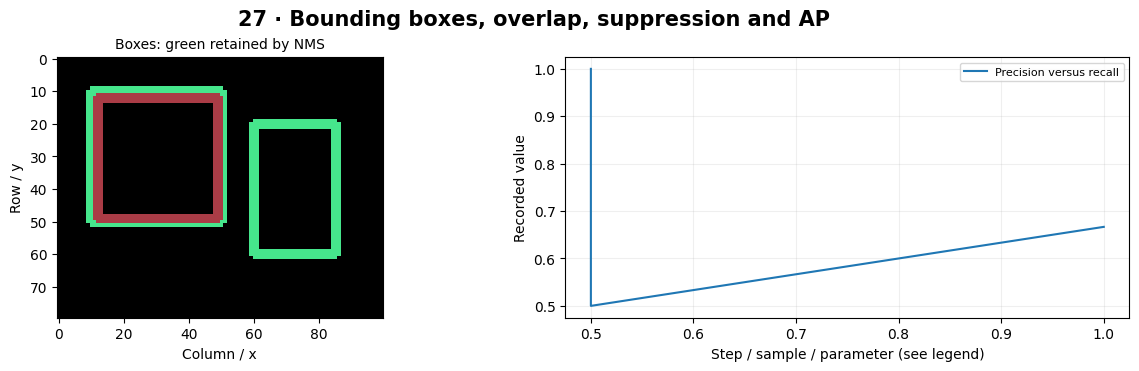

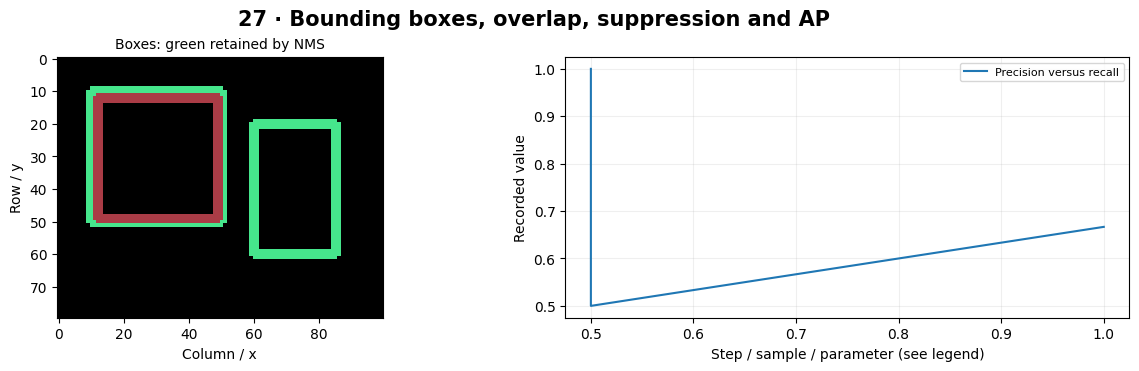

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Detection Evaluation Toolkit**. Implement IoU and NMS before calling a detector API. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

AP50 and COCO-style AP across IoU thresholds are not interchangeable. Coordinate off-by-one conventions matter for small objects.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Raise the NMS IoU threshold and explain the effect on crowded scenes versus duplicate boxes. Keep confidence and IoU thresholds distinct.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Write a one-class evaluator that performs one-to-one matching before AP calculation and tests duplicate detections explicitly.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Greedy NMS keeps the highest-scoring box and removes lower-scoring boxes with excessive overlap, then repeats. Apply class-aware suppression when overlapping objects of different classes can coexist. NMS can remove a real nearby object; modern set-prediction methods may use different duplicate-control mechanisms.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Precision–recall and detector evolution** in this chapter.

[Primary reference](https://cocodataset.org/#detection-eval) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)